# Data Quality Report

This notebook audits all four source sheets used for the TARS exploratory analysis.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


In [2]:
display(sheet_dimensions_report(sheets))

,sheet,rows,columns
0,Clients,2645,6
1,Data,997933,29
2,Schedules,983,11
3,TranslatorsCost+Pairs,4688,7


In [3]:
for short_name, sheet_name in {
    "data": "Data",
    "schedules": "Schedules",
    "clients": "Clients",
    "pairs": "TranslatorsCost+Pairs",
}.items():
    display(Markdown(f"## {sheet_name} dtype audit"))
    audit = dtype_audit(sheets[short_name], sheet_name)
    display(audit)
    mismatches = audit.loc[~audit["matches_expectation"]]
    if not mismatches.empty:
        display(Markdown("Columns with expectation mismatches"))
        display(mismatches)

## Data dtype audit

,column,dtype,expected,matches_expectation
0,PROJECT_ID,string,numeric,False
1,PM,string,unspecified,True
2,TASK_ID,int64,numeric,True
3,START,datetime64[ns],datetime,True
4,END,datetime64[ns],datetime,True
5,TASK_TYPE,string,unspecified,True
6,SOURCE_LANG,string,unspecified,True
7,TARGET_LANG,string,unspecified,True
8,TRANSLATOR,string,unspecified,True
9,ASSIGNED,datetime64[ns],datetime,True


Columns with expectation mismatches

,column,dtype,expected,matches_expectation
0,PROJECT_ID,string,numeric,False


## Schedules dtype audit

,column,dtype,expected,matches_expectation
0,NAME,string,unspecified,True
1,START,string,time_like,True
2,END,string,time_like,True
3,MON,Int64,numeric,True
4,TUES,Int64,numeric,True
5,WED,Int64,numeric,True
6,THURS,Int64,numeric,True
7,FRI,Int64,numeric,True
8,SAT,Int64,numeric,True
9,SUN,Int64,numeric,True


## Clients dtype audit

,column,dtype,expected,matches_expectation
0,CLIENT_NAME,string,categorical,True
1,SELLING_HOURLY_PRICE,int64,numeric,True
2,MIN_QUALITY,float64,numeric,True
3,WILDCARD,string,categorical,True
4,CLIENT_KEY,string,unspecified,True
5,WILDCARD_CLEAN,string,unspecified,True


## TranslatorsCost+Pairs dtype audit

,column,dtype,expected,matches_expectation
0,TRANSLATOR,string,categorical,True
1,SOURCE_LANG,string,categorical,True
2,TARGET_LANG,string,categorical,True
3,HOURLY_RATE,float64,numeric,True
4,TRANSLATOR_KEY,string,unspecified,True
5,SOURCE_LANG_CLEAN,string,unspecified,True
6,TARGET_LANG_CLEAN,string,unspecified,True


## Missing values: Data

,column,missing_count,missing_pct
0,COST,7,0.0
1,HOURLY_RATE,7,0.0
2,END,2,0.0
3,START,1,0.0
4,ASSIGNED,0,0.0
5,CLIENT_KEY,0,0.0
6,CLOSE,0,0.0
7,DELIVERED,0,0.0
8,HOURS,0,0.0
9,MANUFACTURER,0,0.0


## Missing values: Schedules

,column,missing_count,missing_pct
0,END,0,0.0
1,FRI,0,0.0
2,MON,0,0.0
3,NAME,0,0.0
4,NAME_KEY,0,0.0
5,SAT,0,0.0
6,START,0,0.0
7,SUN,0,0.0
8,THURS,0,0.0
9,TUES,0,0.0


## Missing values: Clients

,column,missing_count,missing_pct
0,CLIENT_KEY,0,0.0
1,CLIENT_NAME,0,0.0
2,MIN_QUALITY,0,0.0
3,SELLING_HOURLY_PRICE,0,0.0
4,WILDCARD,0,0.0
5,WILDCARD_CLEAN,0,0.0


## Missing values: TranslatorsCost+Pairs

,column,missing_count,missing_pct
0,HOURLY_RATE,5,0.11
1,SOURCE_LANG,0,0.00
2,SOURCE_LANG_CLEAN,0,0.00
3,TARGET_LANG,0,0.00
4,TARGET_LANG_CLEAN,0,0.00
5,TRANSLATOR,0,0.00
6,TRANSLATOR_KEY,0,0.00


## Missingness correlation for the most-missing Data columns

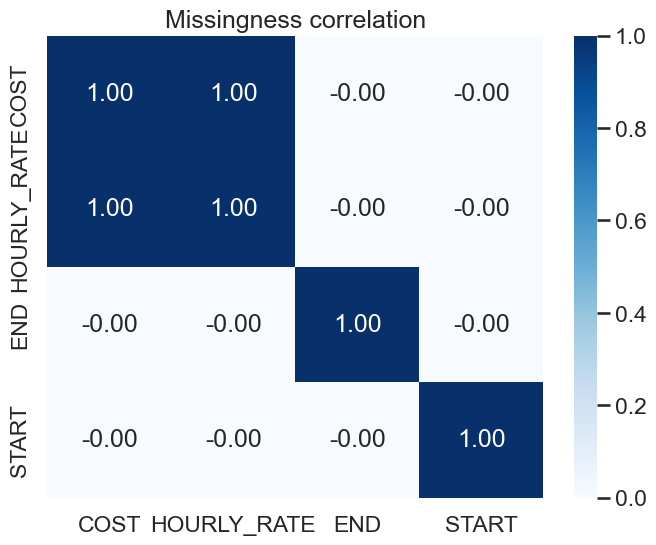

## Missingness by task type

,TASK_TYPE_CLEAN,COST,HOURLY_RATE,END,START
0,DTP,0.000000,0.000000,0.000000,0.000000
1,Engineering,0.000000,0.000000,0.000000,0.000000
2,LanguageLead,0.000000,0.000000,0.000000,0.000000
3,Management,0.000000,0.000000,0.000000,0.000000
4,Miscellaneous,0.003576,0.003576,0.001192,0.000000
5,PostEditing,0.000000,0.000000,0.000000,0.000000
6,ProofReading,0.000232,0.000232,0.000000,0.000232
7,ProofReadingOnly,0.000000,0.000000,0.000000,0.000000
8,Spotcheck,0.000000,0.000000,0.000000,0.000000
9,TEST,0.000000,0.000000,0.000000,0.000000


## Missingness by task start year

,START_YEAR,COST,HOURLY_RATE,END,START
0,1956.0,0.000000,0.000000,0.000000,0.0
1,2009.0,0.000000,0.000000,0.000000,0.0
2,2010.0,0.000000,0.000000,0.000000,0.0
3,2011.0,0.000000,0.000000,0.000000,0.0
4,2012.0,0.005401,0.005401,0.002700,0.0
5,2013.0,0.002241,0.002241,0.000000,0.0
6,2014.0,0.000000,0.000000,0.000000,0.0
7,2015.0,0.001191,0.001191,0.000000,0.0
8,2016.0,0.000000,0.000000,0.000000,0.0
9,2017.0,0.000000,0.000000,0.000000,0.0


In [4]:
for short_name, sheet_name in {
    "data": "Data",
    "schedules": "Schedules",
    "clients": "Clients",
    "pairs": "TranslatorsCost+Pairs",
}.items():
    display(Markdown(f"## Missing values: {sheet_name}"))
    display(missing_summary(sheets[short_name]))

data_missing_cols = missing_summary(data).query("missing_count > 0")["column"].tolist()
top_missing_cols = data_missing_cols[:6]
if top_missing_cols:
    display(Markdown("## Missingness correlation for the most-missing Data columns"))
    corr = missingness_correlation(data[top_missing_cols])
    if not corr.empty:
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
        plt.title("Missingness correlation")
        plt.show()

    display(Markdown("## Missingness by task type"))
    display(missingness_by_group(data, top_missing_cols, "TASK_TYPE_CLEAN").sort_values("TASK_TYPE_CLEAN"))

    display(Markdown("## Missingness by task start year"))
    data_with_year = data.assign(START_YEAR=data["START"].dt.year)
    display(missingness_by_group(data_with_year, top_missing_cols, "START_YEAR").sort_values("START_YEAR"))

In [5]:
duplicate_summary = pd.DataFrame(
    [
        {"sheet": "Data", "exact_duplicate_rows": len(exact_duplicates(data))},
        {"sheet": "Schedules", "exact_duplicate_rows": len(exact_duplicates(schedules))},
        {"sheet": "Clients", "exact_duplicate_rows": len(exact_duplicates(clients))},
        {"sheet": "TranslatorsCost+Pairs", "exact_duplicate_rows": len(exact_duplicates(pairs))},
    ]
)
display(duplicate_summary)

near_dup = near_duplicates_data(data)
near_dup_summary = pd.DataFrame(
    [
        {"check": key, "rows_flagged": len(value)}
        for key, value in near_dup.items()
    ]
)
display(near_dup_summary)

for key, value in near_dup.items():
    display(Markdown(f"### Sample rows: {key}"))
    display(value.head(20))

,sheet,exact_duplicate_rows
0,Data,0
1,Schedules,0
2,Clients,0
3,TranslatorsCost+Pairs,0


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\herme\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py", line 3577, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\herme\AppData\Local\Temp\ipykernel_3440\2228253583.py", line 11, in <module>
    near_dup = near_duplicates_data(data)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\herme\UNI\2\SynthesisProject\SytnthesisProject\data_analysis\_shared\eda_utils.py", line 301, in near_duplicates_data
    data.duplicated(["TRANSLATOR", "START", "END"], keep=False)
  File "c:\Users\herme\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\frame.py", line 6945, in duplicated
    labels, shape = map(list, zip(*map(f, vals)))
                              ^^^^^^^^^^^^^^^^^^
  File "c:\Users\herme\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\frame.py", line 6913, in f
    labels, shape = algorithms.factorize(vals, size_hint=l

,column,count,iqr_outliers,iqr_outlier_pct,zscore_outliers,zscore_outlier_pct,min,p01,median,p99,max
0,HOURS,997933,134403,13.47,15106,1.51,0.0,0.0,0.29,25.02,725.0
1,HOURLY_RATE,997926,75190,7.53,38212,3.83,8.0,11.0,16.00,33.00,62.0
2,COST,997926,132061,13.23,13508,1.35,0.0,0.0,4.94,419.43,14105.0
3,QUALITY_EVALUATION,997933,3001,0.30,3001,0.30,0.0,4.0,7.00,10.00,10.0


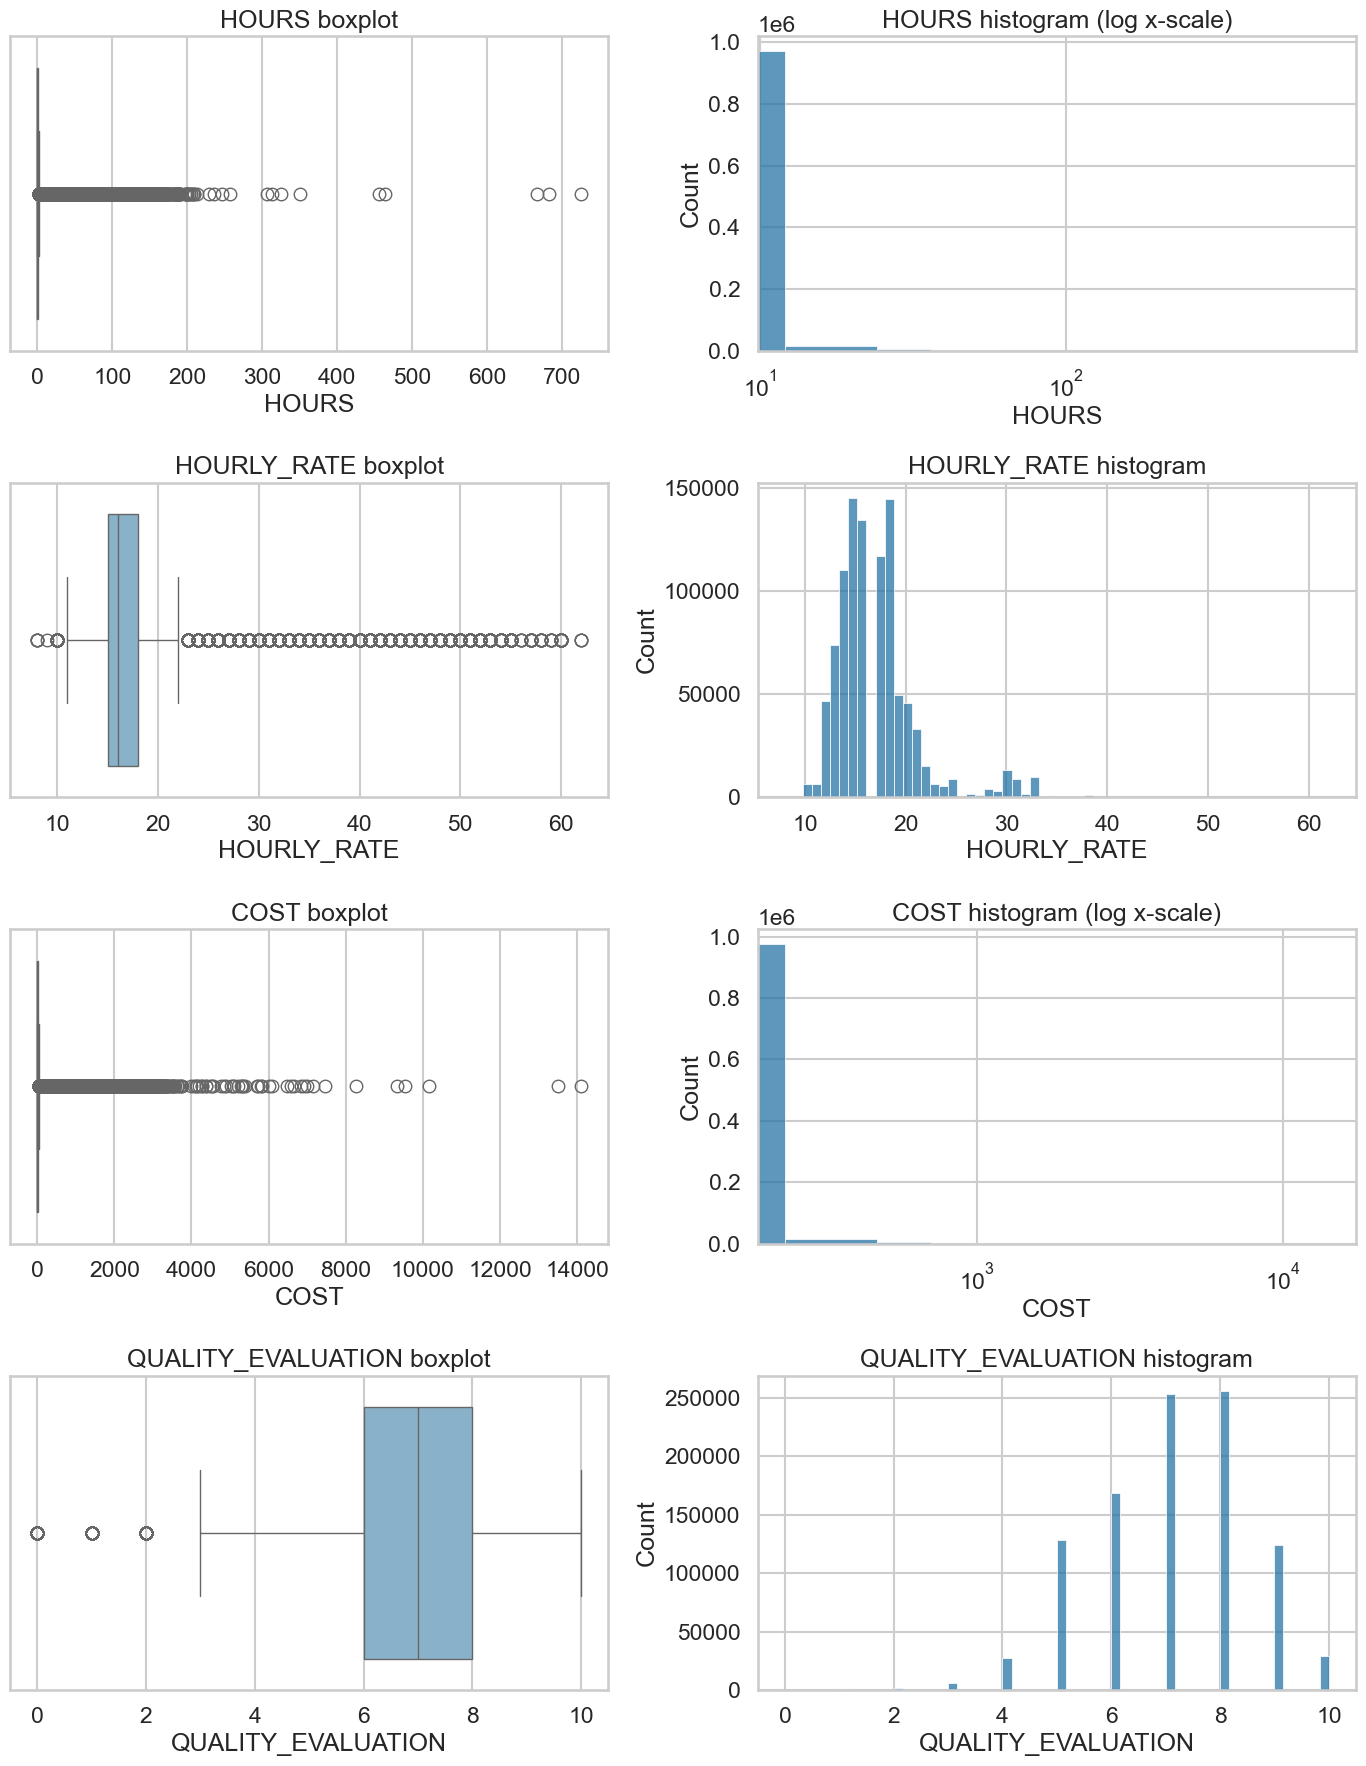

In [ ]:
outlier_report = detect_outliers(data, NUMERIC_OUTLIER_COLUMNS)
display(outlier_report)

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for idx, column in enumerate(NUMERIC_OUTLIER_COLUMNS):
    sns.boxplot(x=data[column], ax=axes[idx, 0], color="#7fb3d5")
    axes[idx, 0].set_title(f"{column} boxplot")

    sns.histplot(data[column].dropna(), bins=60, ax=axes[idx, 1], color="#2874a6")
    axes[idx, 1].set_title(f"{column} histogram")
    if column in {"HOURS", "COST"}:
        axes[idx, 1].set_xscale("log")
        axes[idx, 1].set_title(f"{column} histogram (log x-scale)")
plt.tight_layout()
plt.show()

In [ ]:
display(Markdown("## Categorical inconsistencies"))
for column in ["TASK_TYPE", "SOURCE_LANG", "TARGET_LANG", "TRANSLATOR", "MANUFACTURER"]:
    display(Markdown(f"### Variants for {column}"))
    variants = categorical_variants(data[column])
    display(variants.head(50) if not variants.empty else pd.DataFrame({"message": [f"No multi-variant normalized families detected for {column}."]}))

## Categorical inconsistencies

### Variants for TASK_TYPE

,message
0,No multi-variant normalized families detected ...


### Variants for SOURCE_LANG

,message
0,No multi-variant normalized families detected ...


...

,message
0,No multi-variant normalized families detected ...


### Variants for TRANSLATOR

,message
0,No multi-variant normalized families detected ...


### Variants for MANUFACTURER

,message
0,No multi-variant normalized families detected ...


In [ ]:
display(timestamp_logic_report(data))
violation_samples = timestamp_violation_samples(data)
for check_name, sample_df in violation_samples.items():
    display(Markdown(f"### Sample violations: {check_name}"))
    display(sample_df)

,check,violations,violation_pct
0,START_after_END,36771,3.685
1,ASSIGNED_after_READY,0,0.000
2,READY_after_WORKING,0,0.000
3,WORKING_after_DELIVERED,0,0.000


### Sample violations: START_after_END

,PROJECT_ID,TASK_ID,TRANSLATOR,START,END,ASSIGNED,READY,WORKING,DELIVERED
6405,212331,10048285,Victor,2013-11-01 13:13:00,2013-10-31 19:00:00,2013-10-31 13:14:35,2013-10-31 13:18:25,2013-10-31 13:18:27,2013-10-31 13:18:29
6406,212331,10048286,Maria Alexandra,2013-11-01 13:13:00,2013-10-31 19:00:00,2013-10-31 13:14:35,2013-10-31 13:17:56,2013-10-31 13:17:58,2013-10-31 13:18:03
6407,212331,10048287,Maria Alexandra,2013-11-01 13:13:00,2013-10-31 19:00:00,2013-10-31 13:14:35,2013-10-31 13:16:51,2013-10-31 13:16:54,2013-10-31 13:16:58
32655,220901,11231860,Gala,2023-01-02 09:55:00,2023-01-02 09:53:00,2022-12-30 11:57:35,2023-01-02 08:50:15,2023-01-02 09:01:20,2023-01-02 09:13:20
32663,220930,11231989,Ildefonso Ambrosio,2023-01-02 16:21:00,2023-01-02 16:19:00,2022-12-30 10:40:11,2023-01-02 15:38:45,2023-01-02 15:41:17,2023-01-02 16:43:43
32693,220901,11231652,Gala,2022-12-30 10:16:00,2022-12-30 10:13:00,2022-12-30 08:16:36,2022-12-30 10:17:40,2022-12-30 10:18:06,2022-12-30 10:19:26
32694,220901,11231739,Markel,2022-12-30 14:38:00,2022-12-30 13:35:00,2022-12-30 08:16:30,2022-12-30 13:39:10,2022-12-30 13:45:58,2022-12-30 13:53:41
32696,220901,11231610,Inocencio Lucas,2022-12-30 09:52:00,2022-12-30 09:49:00,2022-12-30 08:16:24,2022-12-30 08:52:33,2022-12-30 09:02:35,2022-12-30 09:13:32
32745,220901,11231422,Gala,2022-12-29 12:59:00,2022-12-29 12:56:00,2022-12-29 08:16:08,2022-12-29 11:57:55,2022-12-29 12:10:04,2022-12-29 12:22:07
32747,220901,11231421,Markel,2022-12-29 12:58:00,2022-12-29 12:55:00,2022-12-29 08:16:03,2022-12-29 12:02:17,2022-12-29 12:13:24,2022-12-29 12:25:26


### Sample violations: ASSIGNED_after_READY

,PROJECT_ID,TASK_ID,TRANSLATOR,START,END,ASSIGNED,READY,WORKING,DELIVERED


### Sample violations: READY_after_WORKING

,PROJECT_ID,TASK_ID,TRANSLATOR,START,END,ASSIGNED,READY,WORKING,DELIVERED


### Sample violations: WORKING_after_DELIVERED

,PROJECT_ID,TASK_ID,TRANSLATOR,START,END,ASSIGNED,READY,WORKING,DELIVERED


In [ ]:
display(zero_value_report(data))

zero_cases = data.loc[(data["HOURS"].fillna(0) == 0) | (data["COST"].fillna(0) == 0)].copy()
display(
    zero_cases.groupby("TASK_TYPE_CLEAN")
    .agg(
        rows=("TASK_ID", "size"),
        total_hours=("HOURS", "sum"),
        total_cost=("COST", "sum"),
        median_duration_hours=("HOURS", "median"),
    )
    .sort_values("rows", ascending=False)
    .head(20)
)

display(same_language_report(data))
display(same_language_examples(data, limit=25))
if not same_language_examples(data, limit=1).empty:
    same_lang_subset = data.loc[
        data["SOURCE_LANG_CLEAN"].eq(data["TARGET_LANG_CLEAN"]),
        ["TRANSLATOR", "MANUFACTURER", "TASK_ID"],
    ]
    display(
        same_lang_subset.groupby("TRANSLATOR").size().sort_values(ascending=False).head(15).rename("tasks").reset_index()
    )
    display(
        same_lang_subset.groupby("MANUFACTURER").size().sort_values(ascending=False).head(15).rename("tasks").reset_index()
    )

,segment,rows,pct_of_tasks,median_hours,median_cost
0,hours_zero,69034,6.918,0.0,0.0
1,cost_zero,69041,6.918,0.0,0.0
2,hours_and_cost_zero,69034,6.918,0.0,0.0


,rows,total_hours,total_cost,median_duration_hours
TASK_TYPE_CLEAN,,,,
ProofReading,49972,0.16,0.0,0.0
Miscellaneous,11310,1.17,0.0,0.0
Translation,5685,4.04,0.0,0.0
PostEditing,922,0.00,0.0,0.0
Engineering,861,0.00,0.0,0.0
LanguageLead,187,0.00,0.0,0.0
Management,47,0.00,0.0,0.0
TEST,29,0.00,0.0,0.0
DTP,26,0.00,0.0,0.0


,metric,value
0,rows,1643.0000
1,share_pct,0.1646
2,unique_translators,153.0000
3,unique_clients,143.0000


,PROJECT_ID,TASK_ID,TASK_TYPE,SOURCE_LANG,TARGET_LANG,TRANSLATOR,MANUFACTURER
1904,215746,10519801,Miscellaneous,Spanish (LA),Spanish (LA),Leila Josafat,PaperPro Packaging
2715,212955,10277460,Engineering,English,English,Victor,Global Trading Solutions
2716,212958,10277459,Engineering,English,English,Victor,GenomicSolutions
2717,212956,10277458,Engineering,English,English,Victor,Voltage Ventures
6405,212331,10048285,Miscellaneous,Catalan,Catalan,Victor,SunTech
26105,209334,10154494,Miscelaneous,Catalan,Catalan,Victor,HealthyLife
26148,209331,10154281,Miscelaneous,Catalan,Catalan,Victor,HealthyLife
26942,209198,10150895,ProofReading,Catalan,Catalan,Luis Felipe,HealthyLife
27931,209037,10146723,Engineering,Catalan,Catalan,Raül,HealthyLife
29017,208696,10140973,Miscellaneous,Catalan,Catalan,Luis Felipe,Global Trading Solutions


,TRANSLATOR,tasks
0,Victor,330
1,Estela,297
2,Maria Alexandra,105
3,Agueda,48
4,Raül,45
5,Connor,39
6,Hector,34
7,Natalie,27
8,Basileo,26
9,Timoteo,26


,MANUFACTURER,tasks
0,AeroSysTech,438
1,HealthyLife,201
2,TechPlanner,192
3,Amplitude Systems Corp.,131
4,Flux Fuel,75
5,MindSpark Media,61
6,AeroIndustries,50
7,TrueConnect,34
8,DesarrolloYa,33
9,IronPulse,23


In [ ]:
display(cross_sheet_consistency_report(data, schedules, clients, pairs))

joined = join_datasets()
client_diag = diagnose_client_unmatched(joined, clients)
pair_diag = diagnose_pair_unmatched(joined, pairs)
schedule_diag = diagnose_schedule_unmatched(joined, schedules)

display(Markdown("## Unmatched client diagnostics"))
display(client_diag["diagnosis"].value_counts(dropna=False).rename_axis("diagnosis").reset_index(name="rows"))
display(client_diag.head(30))

display(Markdown("## Unmatched pair diagnostics"))
display(pair_diag["diagnosis"].value_counts(dropna=False).rename_axis("diagnosis").reset_index(name="rows"))
display(pair_diag.head(30))

display(Markdown("## Unmatched schedule diagnostics"))
display(schedule_diag["diagnosis"].value_counts(dropna=False).rename_axis("diagnosis").reset_index(name="rows"))
display(schedule_diag.head(30))

,check,matched_rows,match_rate_pct,unmatched_rows,unmatched_unique_values
0,Data translators present in Schedules,997933,100.0,0,0
1,Data translators present in TranslatorsCost+Pairs,997933,100.0,0,0
2,Data manufacturers present in Clients,997933,100.0,0,0


## Unmatched client diagnostics

,diagnosis,rows


,MANUFACTURER,diagnosis


## Unmatched pair diagnostics

,diagnosis,rows
0,language_or_name_spelling_variant,5


,TRANSLATOR,SOURCE_LANG,TARGET_LANG,TRANSLATOR_KEY,SOURCE_LANG_CLEAN,TARGET_LANG_CLEAN,diagnosis
0,Acolmiztli,Spanish (LA),Nahuatl,acolmiztli,spanish (la),nahuatl,language_or_name_spelling_variant
1,Citlali,English,Nahuatl,citlali,english,nahuatl,language_or_name_spelling_variant
2,Fiamma Baldomero,Finnish,Spanish (Iberian),fiamma baldomero,finnish,spanish (iberian),language_or_name_spelling_variant
3,Octavi,Finnish,Finnish,octavi,finnish,finnish,language_or_name_spelling_variant
4,Ryan,Finnish,Spanish (Iberian),ryan,finnish,spanish (iberian),language_or_name_spelling_variant


## Unmatched schedule diagnostics

,diagnosis,rows


,TRANSLATOR,diagnosis
